Task 1: Construct Decision Tree models for classification and regression applications

Data Acquisition and Train-Test Splits for Classification

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [10]:
# Split into 80% train and 20% test partition
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [11]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [54]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


Constructing the Decision Tree Classifier

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
from sklearn.metrics import accuracy_score, classification_report

In [15]:
# Initialize Decision Tree Classifier with depth regularization
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)


In [16]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [17]:
# Evaluate performance
clf_preds = tree_clf.predict(X_test_c)

In [18]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [19]:
print("--- Classification Report ---")

--- Classification Report ---


In [20]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



Visualizing the Trained Decision Tree Structure

In [21]:
import matplotlib.pyplot as plt

In [22]:
from sklearn.tree import plot_tree

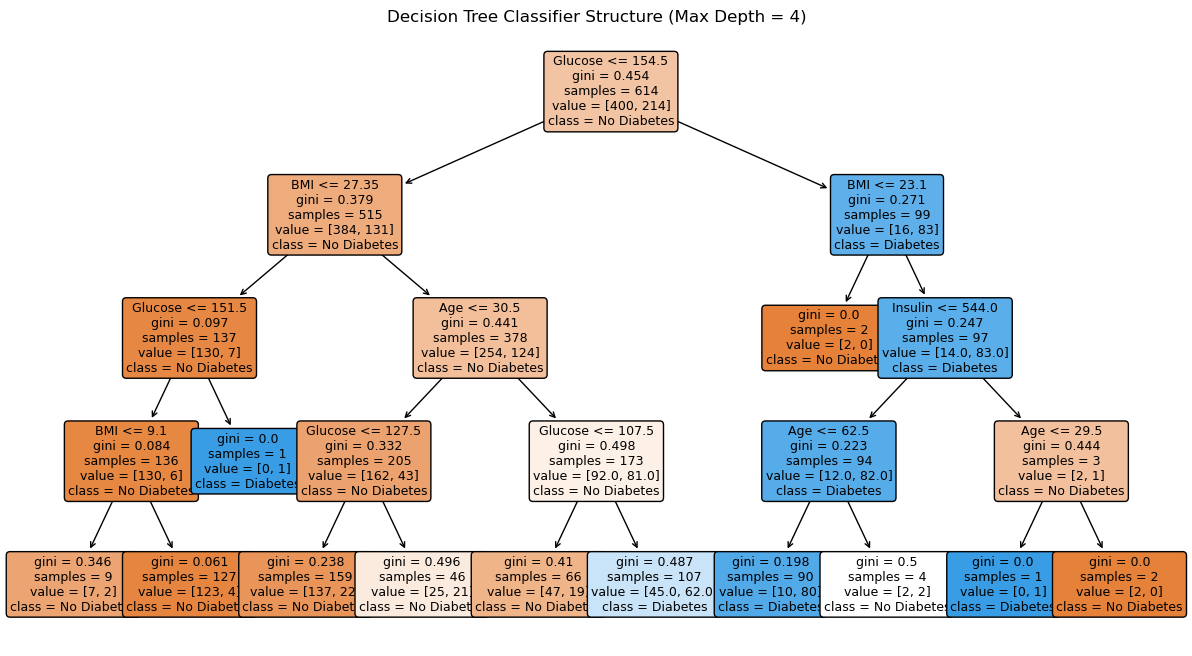

In [53]:
# Plot tree structure
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)")
plt.show()

Constructing a Decision Tree Regressor

In [27]:
from sklearn.tree import DecisionTreeRegressor

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
# Load the Boston Housing dataset from public CSV repository
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [30]:
boston_df = pd.read_csv(boston_url)

In [31]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [32]:
X_boston = boston_df[boston_features]

In [33]:
y_boston = boston_df['medv']

In [34]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [35]:
# Standardize features
scaler_r = StandardScaler()

In [36]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [37]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [38]:
# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [39]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [40]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


Evaluating Decision Tree Regressor Predictions

In [41]:
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
import numpy as np

In [43]:
# Predict and compute metrics
reg_preds = tree_reg.predict(X_test_r_scaled)

In [44]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [45]:
rmse_val = np.sqrt(mse_val)

In [46]:
r2_val = r2_score(y_test_r, reg_preds)

In [47]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [48]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [49]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



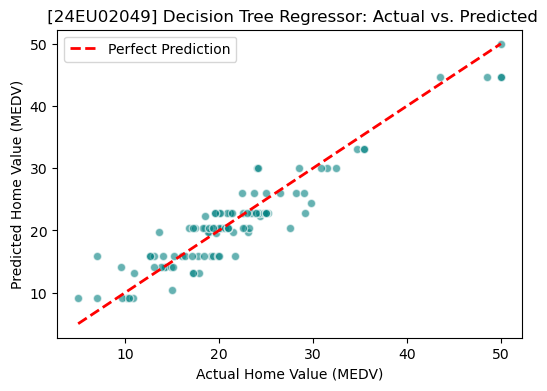

In [52]:
# Plot Actual vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(" [24EU02049] Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

Task 2: Develop ensemble learning models using Bagging, Random Forest, and Voting techniques

Standard Scaling and High-Dimensional Target Map

In [55]:
import warnings

In [56]:
warnings.filterwarnings("ignore")

In [57]:
import pandas as pd

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [61]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [62]:
sonar_columns = sonar_features + ['Class']

In [63]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [64]:
# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [65]:
X_sonar = sonar_df[sonar_features]

In [66]:
y_sonar = sonar_df['Class_numeric']

In [67]:
# Scale features
scaler_sonar = StandardScaler()

In [68]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [69]:
# Split into train/test validation partitions
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [70]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [71]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


Implementing a Bagging Classifier

In [73]:
from sklearn.ensemble import BaggingClassifier

In [72]:
from sklearn.metrics import accuracy_score

In [74]:
# Initialize and train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [75]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [76]:
# Evaluate accuracy
bagging_preds = bagging_model.predict(X_test_s)

In [77]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [78]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


 Implementing a Random Forest Classifier

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


In [81]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [82]:
# Evaluate accuracy
rf_preds = rf_model.predict(X_test_s)

In [83]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [84]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


Implementing a Voting Ensemble Classifier

In [85]:
from sklearn.ensemble import VotingClassifier

In [86]:
from sklearn.linear_model import LogisticRegression

In [87]:
from sklearn.svm import SVC

In [88]:
# Define base estimators
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [89]:
# Initialize and train soft Voting Classifier
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [90]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [91]:
# Evaluate accuracy
voting_preds = voting_model.predict(X_test_s)

In [93]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [94]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


 Performance Comparison of Ensemble Techniques

In [95]:
import matplotlib.pyplot as plt

In [96]:
import seaborn as sns

In [97]:
# Compile results
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [98]:
print("--- Performance Comparison ---")

--- Performance Comparison ---


In [99]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


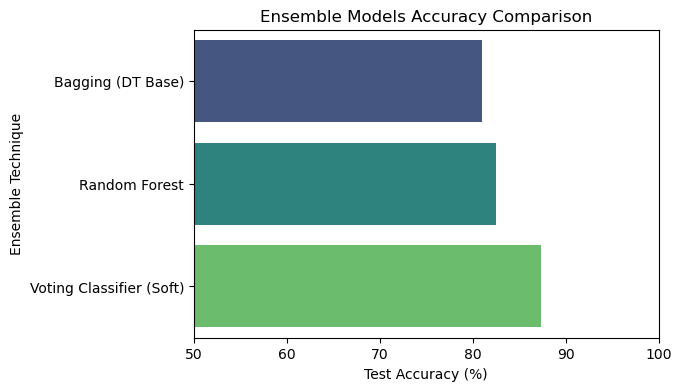

In [100]:
# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison")
plt.show()

Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement

Implementing the AdaBoost Classifier

In [101]:
import warnings

In [102]:
warnings.filterwarnings("ignore")

In [103]:
from sklearn.ensemble import AdaBoostClassifier

In [104]:
from sklearn.metrics import accuracy_score

In [105]:
# Initialize and train AdaBoost Classifier (with default Decision Tree stumps)
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [106]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [107]:
# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)

In [108]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [109]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


Implementing the Gradient Boosting Classifier

In [110]:
from sklearn.ensemble import GradientBoostingClassifier

In [111]:
# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [112]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [113]:
# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)

In [114]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [115]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


Hyperparameter Tuning for Gradient Boosting Classifier

In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [118]:
# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [119]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [120]:
# Extract optimized model and predict
best_gb = grid_gb.best_estimator_

In [121]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [123]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [124]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [125]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


Master Comparison: Ensemble vs. Boosting Models

In [126]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [127]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [128]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting

In [129]:
import matplotlib.pyplot as plt

In [130]:
import numpy as np

In [131]:
# Extract feature importances
rf_importances = rf_model.feature_importances_

In [132]:
gb_importances = best_gb.feature_importances_

In [133]:
# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]

In [134]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [135]:
# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]

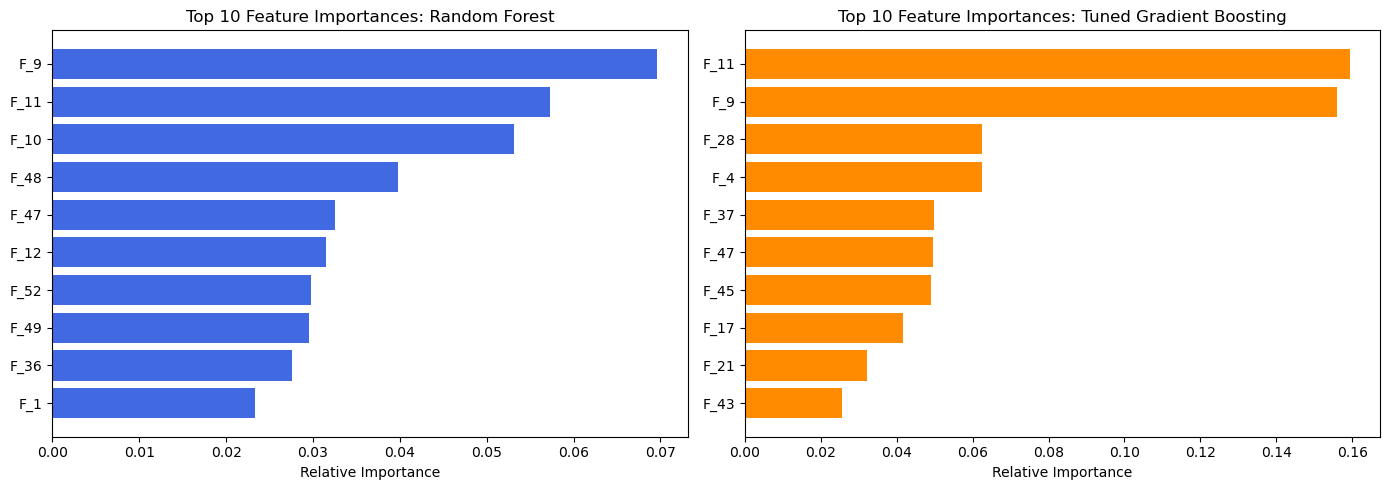

In [138]:
# Set up canvas# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()